# Electricity Appliance Energy Forecasting

## Part 1 – Data Retrieval, Preprocessing and Exploratory Data Analysis

**Module:** Data Analysis with AI

**Dataset:** UCI Appliance Energy Prediction Dataset

**Student:** Your Name

---

## Objectives

The objective of this notebook is to prepare the Appliance Energy Prediction dataset for time-series forecasting. The analysis includes:

- Loading and inspecting the dataset
- Parsing timestamps and indexing the time series
- Data quality assessment
- Resampling the original 10-minute observations to hourly intervals
- Exploratory data analysis (EDA)
- Investigation of trend and seasonality
- Stationarity testing for future forecasting models

The processed dataset produced in this notebook will be used in subsequent notebooks for benchmark forecasting models, SARIMAX modelling, machine learning, and foundation models.

## 1. Import Required Libraries

This section imports all Python libraries required for data manipulation, visualisation, and time-series analysis.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

from scipy.stats import probplot

## 2. Load the Dataset

The Appliance Energy Prediction dataset is loaded from the local project directory. The dataset contains measurements recorded every 10 minutes from a smart home environment, including appliance energy consumption, indoor environmental sensor readings, and outdoor weather variables.

In [3]:
# Load dataset
df = pd.read_csv("../data/energydata_complete.csv")

# First look
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## 3. Initial Dataset Inspection

Before any preprocessing, the dataset is examined to understand its structure.

The following information is inspected:

- Number of observations
- Number of variables
- Data types
- Memory usage
- First few records

In [4]:
print("Shape:", df.shape)

df.info()

Shape: (19735, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null

## 4. Timestamp Parsing

The **date** column is converted into a datetime format and used as the DataFrame index.

Using a datetime index enables efficient time-series operations including:

- Resampling
- Rolling statistics
- Seasonal decomposition
- Forecasting

In [5]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df.set_index("date", inplace=True)

df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## 5. Data Quality Assessment

Good forecasting models require clean data.

The dataset is checked for:

- Missing values
- Duplicate observations
- Invalid timestamps
- Summary statistics

Any issues identified will be addressed before modelling.

In [6]:
missing = df.isnull().sum()

print(missing)

Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.694958,102.524891,10.000000,50.000000,60.000000,100.000000,1080.000000
lights,19735.0,3.801875,7.935988,0.000000,0.000000,0.000000,0.000000,70.000000
T1,19735.0,21.686571,1.606066,16.790000,20.760000,21.600000,22.600000,26.260000
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.360000
T2,19735.0,20.341219,2.192974,16.100000,18.790000,20.000000,21.500000,29.856667
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,40.500000,43.260000,56.026667
T3,19735.0,22.267611,2.006111,17.200000,20.790000,22.100000,23.290000,29.236000
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,38.530000,41.760000,50.163333
T4,19735.0,20.855335,2.042884,15.100000,19.530000,20.666667,22.100000,26.200000
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,38.400000,42.156667,51.090000


## 6. Hourly Resampling

The original dataset is recorded every **10 minutes**.

To satisfy the assignment requirements, the data are aggregated into **hourly observations** using the mean value within each hour.

Hourly aggregation reduces noise while preserving the overall temporal behaviour of appliance energy demand.

In [9]:
hourly_df = df.resample("H").mean()

hourly_df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,55.000000,35.000000,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,...,17.016667,45.446667,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000,26.823044,26.823044
2016-01-11 18:00:00,176.666667,51.666667,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,...,16.981667,45.290000,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333,22.324206,22.324206
2016-01-11 19:00:00,173.333333,25.000000,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,...,16.902222,45.311389,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667,33.734932,33.734932
2016-01-11 20:00:00,125.000000,35.000000,20.961111,48.453333,20.251111,45.632639,20.213889,47.268889,19.190833,49.227917,...,16.890000,45.118889,6.000000,735.283333,87.583333,6.000000,40.000000,4.016667,25.679642,25.679642
2016-01-11 21:00:00,103.333333,23.333333,21.311667,45.768333,20.587778,44.961111,20.373333,46.164444,19.425556,47.918889,...,16.890000,44.807778,5.833333,735.566667,87.416667,6.000000,40.000000,3.816667,18.826274,18.826274


In [10]:
print(hourly_df.shape)

(3290, 28)


In [11]:
hourly_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3290 entries, 2016-01-11 17:00:00 to 2016-05-27 18:00:00
Freq: h
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   3290 non-null   float64
 1   lights       3290 non-null   float64
 2   T1           3290 non-null   float64
 3   RH_1         3290 non-null   float64
 4   T2           3290 non-null   float64
 5   RH_2         3290 non-null   float64
 6   T3           3290 non-null   float64
 7   RH_3         3290 non-null   float64
 8   T4           3290 non-null   float64
 9   RH_4         3290 non-null   float64
 10  T5           3290 non-null   float64
 11  RH_5         3290 non-null   float64
 12  T6           3290 non-null   float64
 13  RH_6         3290 non-null   float64
 14  T7           3290 non-null   float64
 15  RH_7         3290 non-null   float64
 16  T8           3290 non-null   float64
 17  RH_8         3290 non-null   float64
 18  T9  

In [12]:
hourly_df.isnull().sum()

Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

## 7. Exploratory Data Analysis

Several visualisations are produced to understand the characteristics of appliance energy consumption.

The analysis investigates:

- Overall temporal behaviour
- Distribution of observations
- Presence of outliers
- Correlation between variables
- Daily and weekly usage patterns

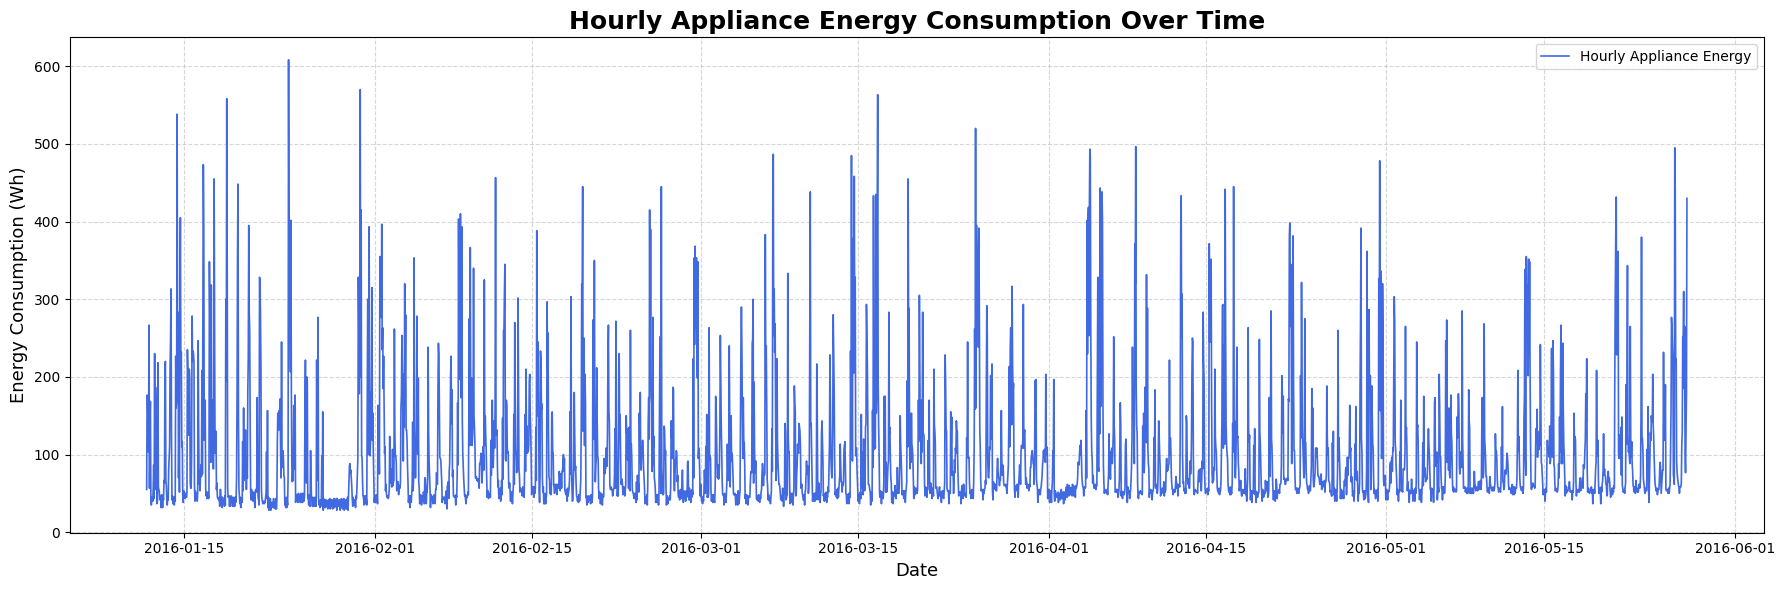

In [43]:
plt.figure(figsize=(18,6))

plt.plot(
    hourly_df.index,
    hourly_df["Appliances"],
    color="royalblue",
    linewidth=1.2,
    label="Hourly Appliance Energy"
)

plt.title(
    "Hourly Appliance Energy Consumption Over Time",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=13)

plt.ylabel("Energy Consumption (Wh)", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.5)

plt.legend()

plt.tight_layout()

plt.savefig("../outputs/figures/appliance_timeseries.png", dpi=300)

plt.show()

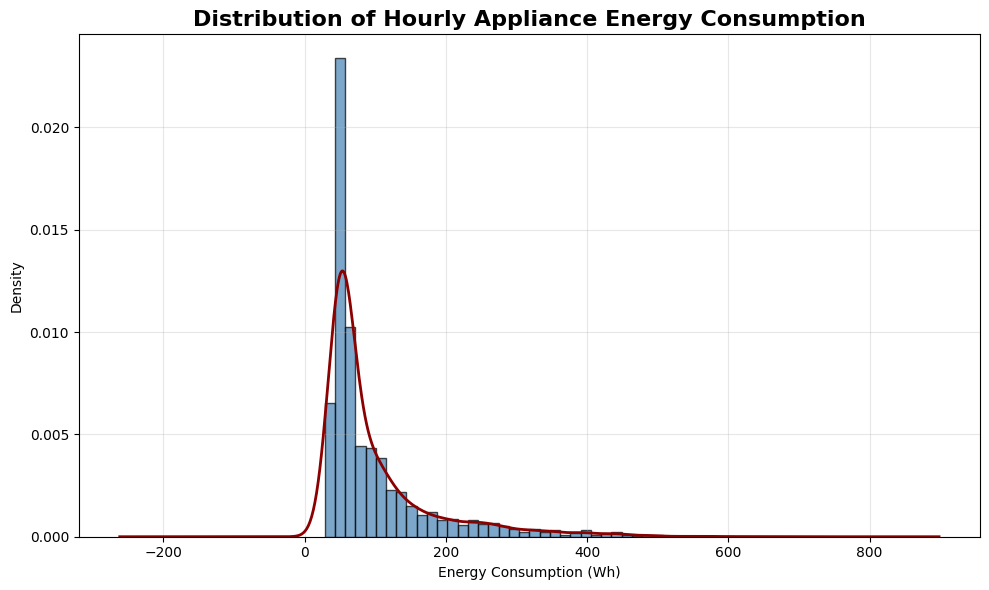

In [44]:
plt.figure(figsize=(10,6))

hourly_df["Appliances"].plot(
    kind="hist",
    bins=40,
    density=True,
    alpha=0.7,
    color="steelblue",
    edgecolor="black"
)

hourly_df["Appliances"].plot(
    kind="kde",
    linewidth=2,
    color="darkred"
)

plt.title(
    "Distribution of Hourly Appliance Energy Consumption",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Energy Consumption (Wh)")

plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../outputs/figures/distribution.png", dpi=300)

plt.show()

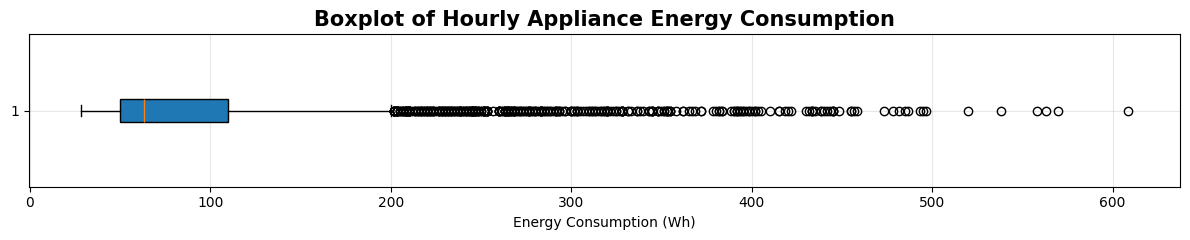

In [45]:
plt.figure(figsize=(12,2.5))

plt.boxplot(
    hourly_df["Appliances"],
    vert=False,
    patch_artist=True
)

plt.title(
    "Boxplot of Hourly Appliance Energy Consumption",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Energy Consumption (Wh)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../outputs/figures/boxplot.png", dpi=300)

plt.show()

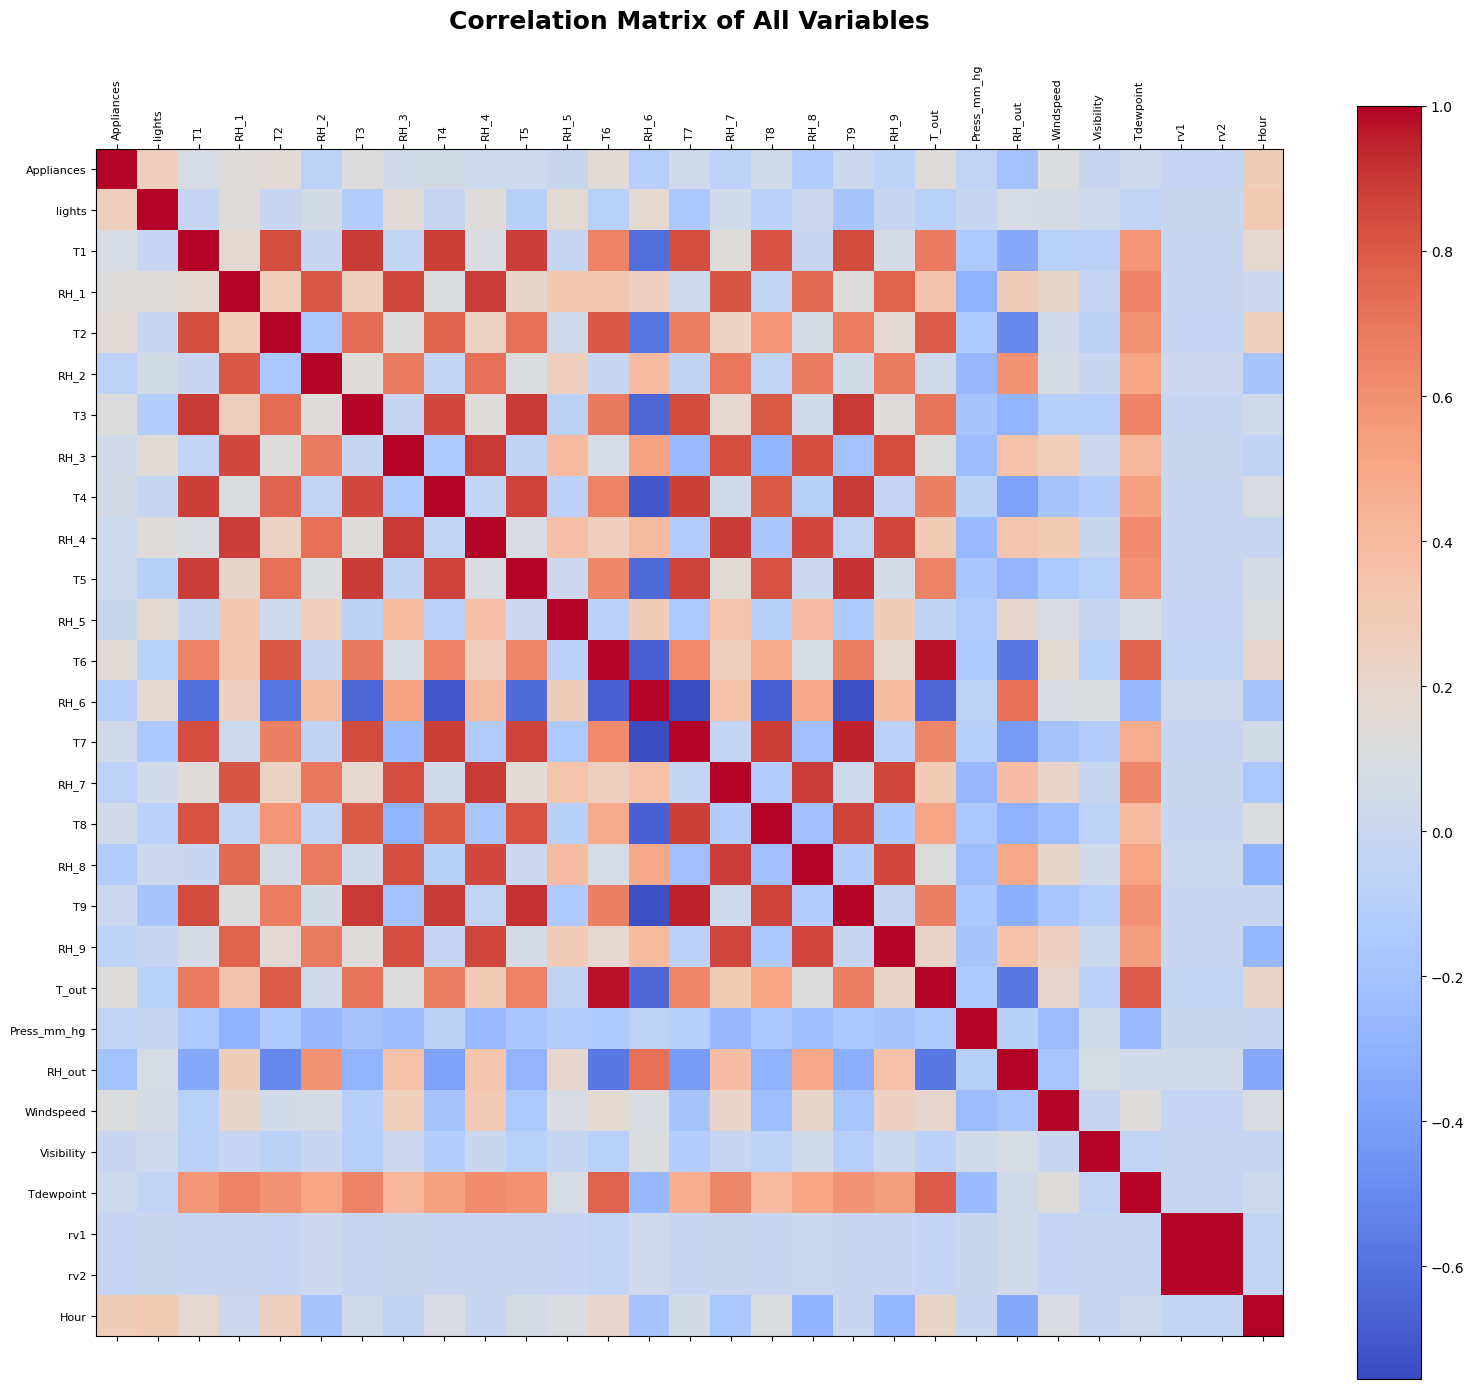

In [46]:
import matplotlib.pyplot as plt

corr = hourly_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(16,14))

cax = ax.matshow(corr, cmap="coolwarm")

plt.colorbar(cax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)

plt.title(
    "Correlation Matrix of All Variables",
    fontsize=18,
    pad=25,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig("../outputs/figures/correlation_matrix.png", dpi=300)

plt.show()

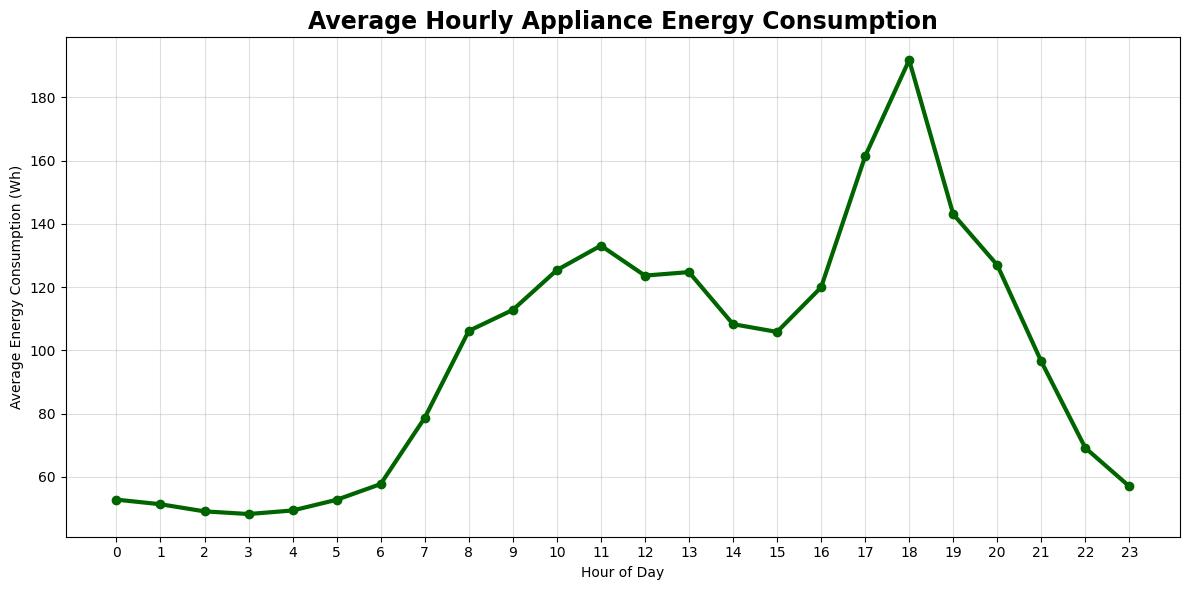

In [47]:
hourly_pattern = (
    hourly_df
    .groupby(hourly_df.index.hour)["Appliances"]
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    hourly_pattern.index,
    hourly_pattern.values,
    marker="o",
    linewidth=3,
    color="darkgreen"
)

plt.xticks(range(24))

plt.title(
    "Average Hourly Appliance Energy Consumption",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Hour of Day")

plt.ylabel("Average Energy Consumption (Wh)")

plt.grid(alpha=0.4)

plt.tight_layout()

plt.savefig("../outputs/figures/daily_pattern.png", dpi=300)

plt.show()

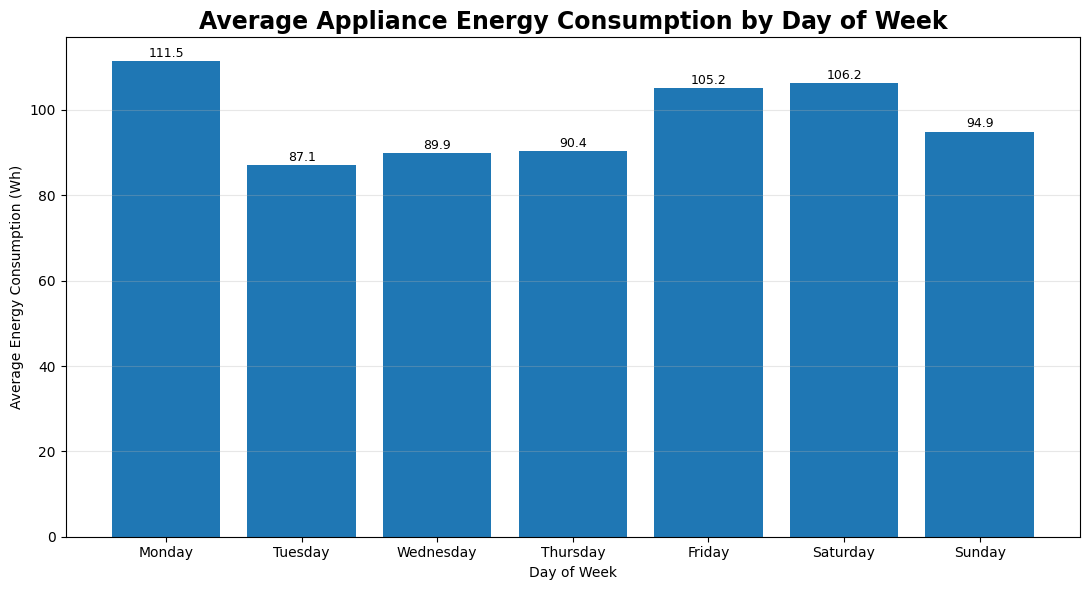

In [48]:
weekday_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

weekday = (
    hourly_df
    .groupby(hourly_df.index.day_name())["Appliances"]
    .mean()
    .reindex(weekday_order)
)

plt.figure(figsize=(11,6))

bars = plt.bar(
    weekday.index,
    weekday.values
)

plt.title(
    "Average Appliance Energy Consumption by Day of Week",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Day of Week")

plt.ylabel("Average Energy Consumption (Wh)")

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+1,
        f"{bar.get_height():.1f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig("../outputs/figures/weekly_pattern.png", dpi=300)

plt.show()

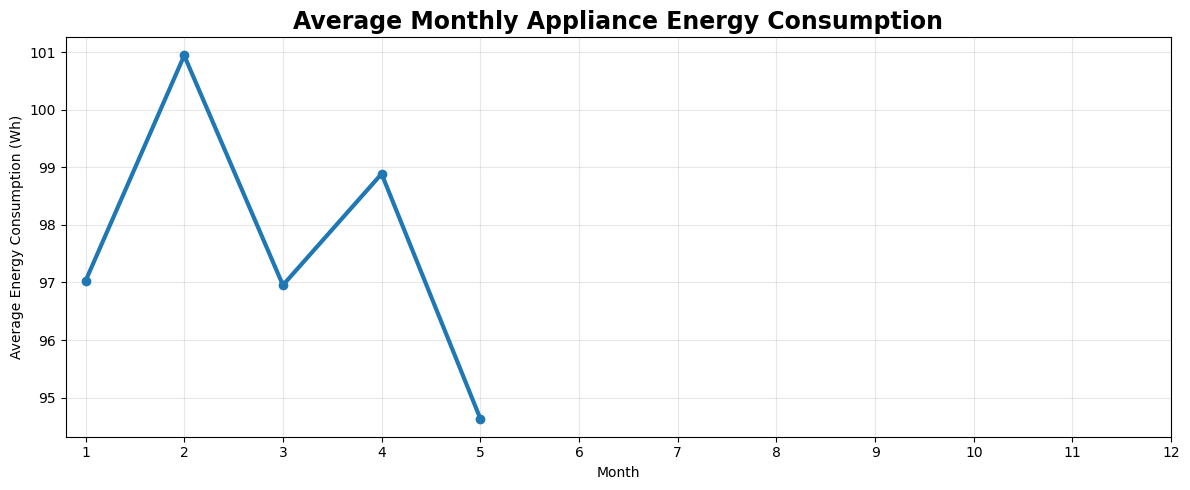

In [49]:
monthly = (
    hourly_df
    .groupby(hourly_df.index.month)["Appliances"]
    .mean()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o",
    linewidth=3
)

plt.xticks(range(1,13))

plt.title(
    "Average Monthly Appliance Energy Consumption",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Month")

plt.ylabel("Average Energy Consumption (Wh)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../outputs/figures/monthly_pattern.png", dpi=300)

plt.show()

## 8. Time-Series Stationarity Analysis

Before applying autoregressive forecasting models such as SARIMA and SARIMAX, the stationarity properties of the appliance energy consumption series must be examined.

A stationary time series has statistical properties that remain constant over time, including:

- Constant mean
- Constant variance
- Time-independent autocorrelation structure

Many statistical forecasting models require stationary input data. Therefore, this section investigates whether differencing is required.

The following methods are used:

1. Rolling mean and rolling standard deviation analysis
2. Augmented Dickey-Fuller (ADF) test
3. KPSS stationarity test
4. Autocorrelation Function (ACF)
5. Partial Autocorrelation Function (PACF)

### 8.1 Rolling Statistics

Rolling statistics provide a visual assessment of stationarity.

If the rolling mean and standard deviation remain approximately constant, the series is likely stationary.

Large changes indicate possible trends, seasonal effects, or changing variance.

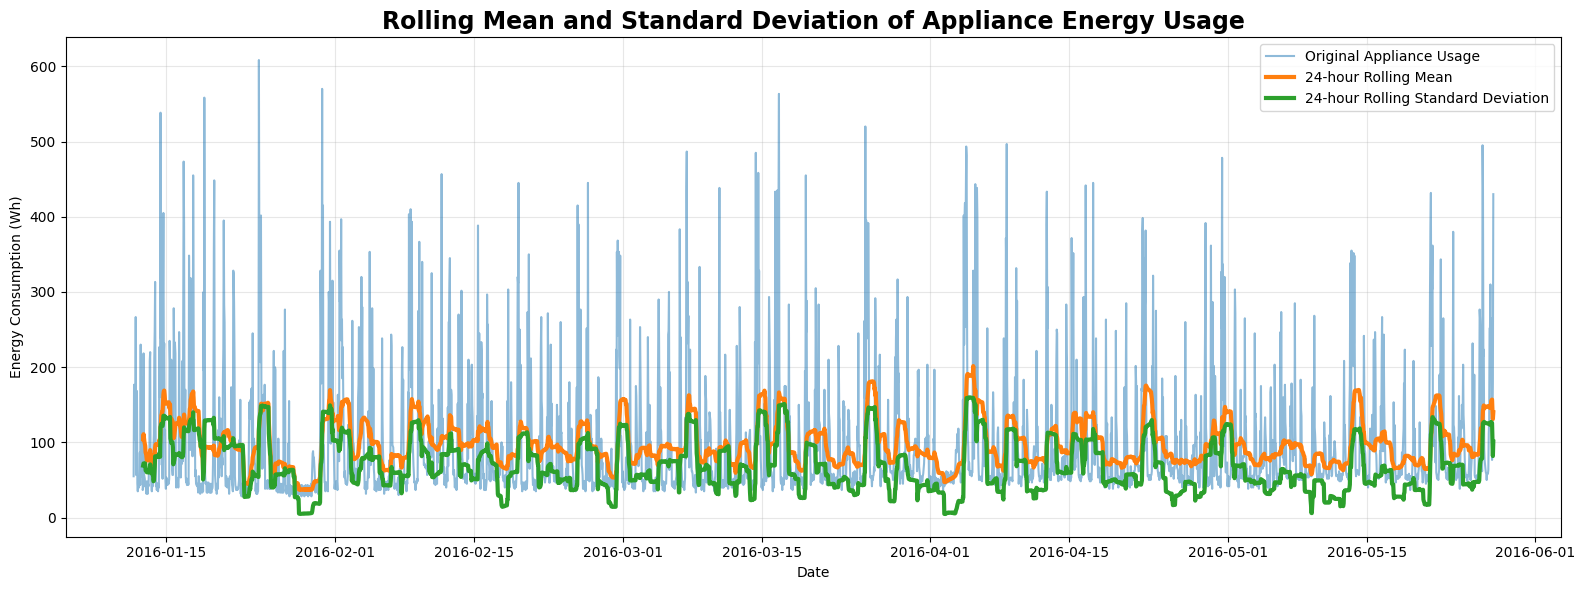

In [50]:
rolling_window = 24   # 24 hours = one day

rolling_mean = (
    hourly_df["Appliances"]
    .rolling(window=rolling_window)
    .mean()
)

rolling_std = (
    hourly_df["Appliances"]
    .rolling(window=rolling_window)
    .std()
)


plt.figure(figsize=(16,6))

plt.plot(
    hourly_df.index,
    hourly_df["Appliances"],
    label="Original Appliance Usage",
    alpha=0.5
)

plt.plot(
    rolling_mean.index,
    rolling_mean,
    linewidth=3,
    label="24-hour Rolling Mean"
)

plt.plot(
    rolling_std.index,
    rolling_std,
    linewidth=3,
    label="24-hour Rolling Standard Deviation"
)


plt.title(
    "Rolling Mean and Standard Deviation of Appliance Energy Usage",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Date")

plt.ylabel("Energy Consumption (Wh)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/rolling_statistics.png",
    dpi=300
)

plt.show()

The rolling statistics indicate that appliance energy consumption does not maintain a perfectly constant mean over the entire period. The rolling mean fluctuates due to daily usage patterns and changes in household activity.

The rolling standard deviation also varies, suggesting that the variance of the series changes over time.

Therefore, the raw appliance energy series shows evidence of non-stationary behaviour. Formal statistical tests are performed next to confirm these observations.

## 8.2 Augmented Dickey-Fuller (ADF) Test

The Augmented Dickey-Fuller test evaluates whether a time series contains a unit root.

Hypotheses:

**Null hypothesis (H0):**
The series is non-stationary.

**Alternative hypothesis (H1):**
The series is stationary.

Decision rule:

- p-value < 0.05 → reject H0 → stationary
- p-value > 0.05 → fail to reject H0 → non-stationary

In [35]:
def adf_test(series):

    result = adfuller(
        series.dropna()
    )

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    print("\nCritical Values:")

    for key,value in result[4].items():
        print(
            f"{key}: {value}"
        )


adf_test(hourly_df["Appliances"])

ADF Statistic: -8.948888280256897
p-value: 8.833753129593983e-15

Critical Values:
1%: -3.432357502010421
5%: -2.862426994644342
10%: -2.567242166152283


## 8.3 KPSS Stationarity Test

The KPSS test provides complementary evidence to the ADF test.

Hypotheses:

**Null hypothesis (H0):**
The series is stationary.

**Alternative hypothesis (H1):**
The series is non-stationary.

Decision rule:

- p-value < 0.05 → reject H0 → non-stationary
- p-value > 0.05 → stationary

In [37]:
from statsmodels.tsa.stattools import kpss


def kpss_test(series):

    statistic, p_value, lags, critical_values = kpss(
        series.dropna(),
        regression="c",
        nlags="auto"
    )

    print("KPSS Statistic:", statistic)
    print("p-value:", p_value)

    print("\nCritical Values:")

    for key,value in critical_values.items():
        print(
            f"{key}: {value}"
        )


kpss_test(hourly_df["Appliances"])

KPSS Statistic: 0.03839879299909173
p-value: 0.1

Critical Values:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\gms\AppData\Local\Temp\ipykernel_13476\1198640637.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(


## 8.4 Autocorrelation Analysis

Autocorrelation analysis investigates the relationship between current appliance energy consumption and previous observations.

The ACF plot helps identify:

- Persistence in the time series
- Seasonal patterns
- Appropriate autoregressive terms

<Figure size 1400x600 with 0 Axes>

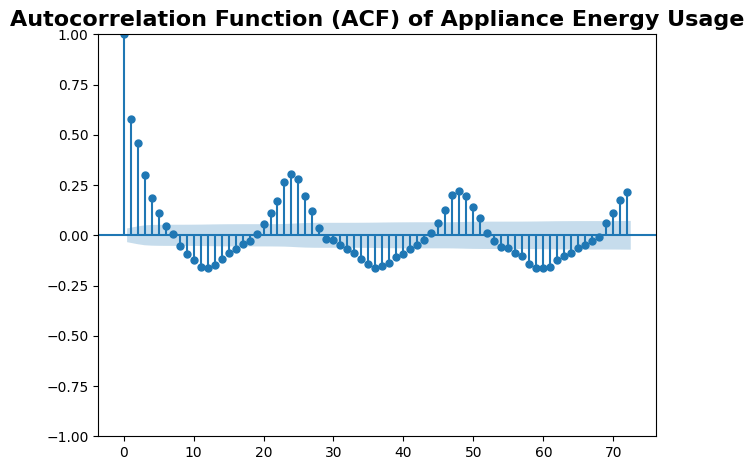

In [51]:
from statsmodels.graphics.tsaplots import plot_acf


plt.figure(figsize=(14,6))

plot_acf(
    hourly_df["Appliances"],
    lags=72
)

plt.title(
    "Autocorrelation Function (ACF) of Appliance Energy Usage",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/acf_plot.png",
    dpi=300
)
plt.show()

## 8.5 Partial Autocorrelation Analysis

The PACF plot measures the direct relationship between observations after removing the influence of intermediate lags.

It helps identify potential autoregressive parameters (p) for SARIMA models.

<Figure size 1400x600 with 0 Axes>

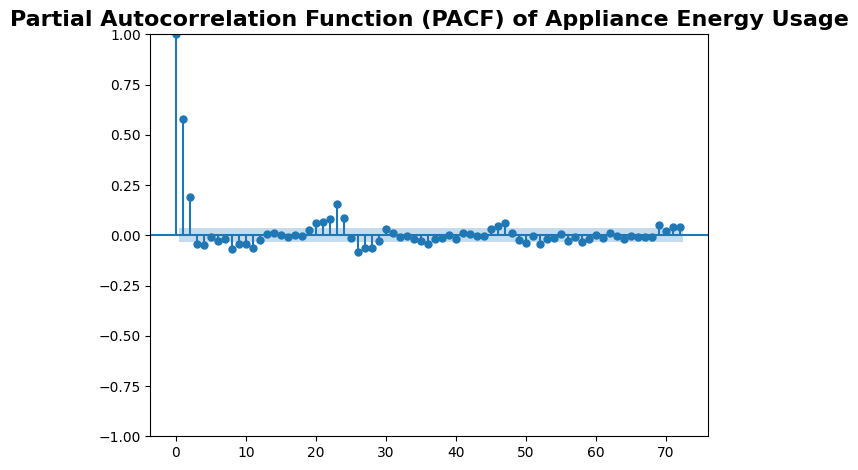

In [52]:
from statsmodels.graphics.tsaplots import plot_pacf


plt.figure(figsize=(14,6))

plot_pacf(
    hourly_df["Appliances"],
    lags=72,
    method="ywm"
)

plt.title(
    "Partial Autocorrelation Function (PACF) of Appliance Energy Usage",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/pacf_plot.png",
    dpi=300
)
plt.show()

## 9. Save Processed Dataset

The cleaned hourly dataset is saved for use in subsequent modelling stages.

This ensures that all forecasting models use the same preprocessed data, improving reproducibility.

In [42]:
hourly_df.to_csv(
    "../data/hourly_energy_data.csv"
)

print(
    "Hourly dataset saved successfully."
)

Hourly dataset saved successfully.
